# Hitfinder Benchmark

Benchmarks all available hitfinder backends on a HIT frame from the ePix10k Resonet CXI file.

**File:** `/data/bioxfel/user/gihan/Resonet/production/epix10k_20k/compressed0.cxi`  
**Frame:** 1 (label = 1.0 → HIT)  
**Pipeline order:** assemble → hitfinder → GCN(full frame) → …

Hitfinders benchmarked:
1. `MockHitfinder` — always returns 0 peaks (baseline / timing floor)
2. `NumpyPF8Hitfinder` — pure NumPy/SciPy PF8 (`threshold=800`, `min_snr=5.0`, `min_pix=2`)
3. `PF8HitfinderPythonWrapper` — ssc Cython PF8 wrapper (`threshold=800`, `min_snr=5.0`, `min_pix=2`)
4. `PF8Hitfinder` — C-extension PF8 (`threshold=800`, `min_snr=5.0`, `min_pix=2`)
5. `GPUHitfinder` + `gpu_pf8.py` — pyFAI OCL_PeakFinder (`cutoff_peak=7.0`, `connected=2`, `min_adu=800`)

In [115]:
import sys
import os

# Add project root to path so `from src.*` imports work.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: /data/bioxfel/user/gihan/Hit_finder


In [116]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# hdf5plugin MUST be imported before h5py to register the bitshuffle filter.
import hdf5plugin  # noqa: F401
import h5py

## Global hitfinder configuration

Edit the cell below to change parameters for **all** backends at once.

In [117]:
# ── Shared hitfinder parameters — edit here, applies to every backend ─────────
MIN_ADU  = 800.0   # absolute intensity floor (ADU); PF8: threshold, GPU: MIN_INTENSITY
MIN_SNR  = 5.0     # local SNR threshold; PF8 backends only (min_snr)
MIN_PIX  = 2       # minimum connected pixels per peak; PF8: min_pix_count, GPU: CONNECTED
MAX_PIX  = 200     # maximum pixels per peak cluster; PF8: max_pix_count
MIN_RES  = 0       # min distance from frame centre (px); 0 = disabled
MAX_RES  = 0       # max distance from frame centre (px); 0 = disabled

# GPU-specific SNR threshold — OCL_PeakFinder uses azimuthal background (different
# scale from the local-box SNR of PF8), so it needs its own knob.
GPU_CUTOFF_PEAK = 15.0

print("Hitfinder config:")
print(f"  MIN_ADU         = {MIN_ADU}")
print(f"  MIN_SNR         = {MIN_SNR}  (PF8 backends)")
print(f"  GPU_CUTOFF_PEAK = {GPU_CUTOFF_PEAK}  (GPU backend)")
print(f"  MIN_PIX / MAX_PIX = {MIN_PIX} / {MAX_PIX}")
print(f"  MIN_RES / MAX_RES = {MIN_RES} / {MAX_RES}  (0 = disabled)")

Hitfinder config:
  MIN_ADU         = 800.0
  MIN_SNR         = 5.0  (PF8 backends)
  GPU_CUTOFF_PEAK = 15.0  (GPU backend)
  MIN_PIX / MAX_PIX = 2 / 200
  MIN_RES / MAX_RES = 0 / 0  (0 = disabled)


## 1. Load frame and detector geometry

We use **frame 1** from the ePix10k CXI file — confirmed as a HIT (label = 1.0), so
Bragg peaks are expected and peak counts are meaningful for comparison.

Three geometry scalars are read directly from the CXI metadata:
- `distance` — sample-to-detector distance (m), used by pyFAI for radial calibration
- `wavelength` — X-ray wavelength (m), used by pyFAI for q/resolution conversion
- `x_pixel_size` — physical pixel pitch (m), used by pyFAI and OCL_PeakFinder

These are passed to `GPUHitfinder.set_geometry()` so the pyFAI integrator is calibrated
to the actual experiment geometry rather than placeholder defaults.

In [118]:
EIGER_CXI_PATH = "/data/bioxfel/user/gihan/Resonet/production/eiger4m_20k/compressed1.cxi"
EPIX_CXI_PATH = "/data/bioxfel/user/gihan/Resonet/production/epix10k_20k/compressed0.cxi"
FRAME_IDX = 1

with h5py.File(EPIX_CXI_PATH, "r") as f:
    # Raw frame — shape (5632, 384) for Eiger4M panel-stacked layout.
    raw_frame = f["entry_1/data_1/data"][FRAME_IDX].astype(np.float32)
    hit_label = float(f["entry_1/labels/hit"][FRAME_IDX])

    dist       = float(f["entry_1/instrument_1/detector_1/distance"][()])
    wavelength = float(f["entry_1/instrument_1/source_1/wavelength"][()])
    pixel_size = float(f["entry_1/instrument_1/detector_1/x_pixel_size"][()])

print(f"Raw frame shape : {raw_frame.shape}")
print(f"Hit label       : {hit_label}  ({'HIT' if hit_label == 1.0 else 'NON-HIT'})")
print(f"Detector dist   : {dist} m")
print(f"Wavelength      : {wavelength:.4e} m")
print(f"Pixel size      : {pixel_size:.2e} m")

Raw frame shape : (5632, 384)
Hit label       : 1.0  (HIT)
Detector dist   : 0.096 m
Wavelength      : 1.3051e-10 m
Pixel size      : 1.00e-04 m


In [119]:
from src.preprocessing.geometry import get_geometry
from src.preprocessing.pipeline import assemble_only
from reborn.detector import PADAssembler

pads      = get_geometry("ePix10k 2.2M")
assembler = PADAssembler(pad_geometry=pads)

assembled = assemble_only(raw_frame, pads, "ePix10k 2.2M", assembler=assembler)

print(f"Assembled shape : {assembled.shape}")
print(f"Intensity range : [{assembled.min():.1f}, {assembled.max():.1f}] ADU")

Assembled shape : (1667, 1667)
Intensity range : [0.0, 11000.0] ADU


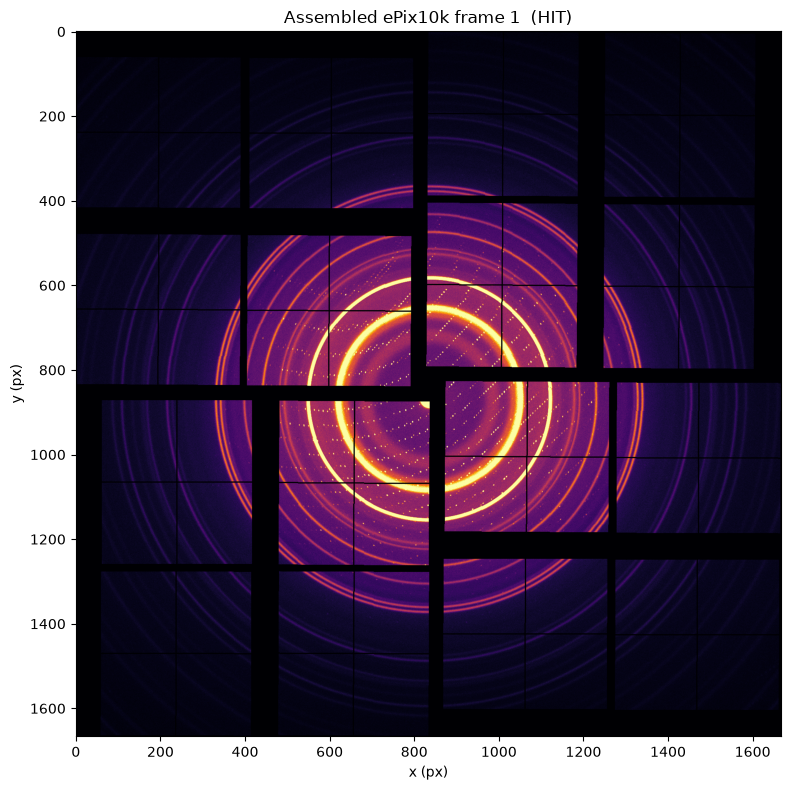

In [120]:
fig, ax = plt.subplots(figsize=(8, 8))
vmin, vmax = np.percentile(assembled, [1, 99])
ax.imshow(assembled, cmap="inferno", vmin=vmin, vmax=vmax, origin="upper")
ax.set_title(f"Assembled ePix10k frame {FRAME_IDX}  ({'HIT' if hit_label else 'NON-HIT'})")
ax.set_xlabel("x (px)")
ax.set_ylabel("y (px)")
plt.tight_layout()
plt.show()

## 2. Run each hitfinder and record timing

All backends receive the **same raw assembled frame** (pre-GCN, pre-LCN) and are asked
to return `(N_peaks, 2)` float32 centroids in `[x, y]` pixel coordinates.

### Parameter alignment across backends

To make peak counts comparable, all backends are configured with equivalent thresholds:

| Backend | Absolute floor | SNR threshold | Min pixels/peak |
|---------|---------------|---------------|-----------------|
| NumpyPF8 | `threshold=800 ADU` | `min_snr=5.0` | `min_pix=2` |
| PF8 Python wrapper | `threshold=800 ADU` | `min_snr=5.0` | `min_pix=2` |
| PF8 (C extension) | `threshold=800 ADU` | `min_snr=5.0` | `min_pix=2` |
| GPU (OCL_PeakFinder) | `MIN_INTENSITY=800 ADU`¹ | `cutoff_peak=7.0`² | `connected=2` |

¹ Applied as a post-filter on OCL centroids — `peakfinder8` has no native ADU gate.  
² `cutoff_peak` is the azimuthal-background σ threshold; 7.0 is stricter than the
  PF8 `min_snr=5.0` local-box SNR to compensate for the difference in background model.

Timing uses **1 warmup + 5 timed runs** to avoid JIT / kernel-compilation artefacts on
the first call (especially important for the GPU backend).

In [121]:
def time_hitfinder(hf, frame: np.ndarray, n_warmup: int = 1, n_runs: int = 5):
    """Run hitfinder n_warmup + n_runs times; return (peaks, mean_ms, std_ms)."""
    peaks = None
    for _ in range(n_warmup):
        peaks = hf.find_peaks(frame)

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        peaks = hf.find_peaks(frame)
        times.append((time.perf_counter() - t0) * 1e3)

    return peaks, float(np.mean(times)), float(np.std(times))

In [122]:
results = []  # list of dicts: {name, peaks, mean_ms, std_ms, available}

# ── 1. MockHitfinder ──────────────────────────────────────────────────────────
from src.hitfinders.base import MockHitfinder

mock_hf = MockHitfinder()
peaks, mean_ms, std_ms = time_hitfinder(mock_hf, assembled)
results.append({"name": "MockHitfinder", "peaks": peaks, "mean_ms": mean_ms,
                "std_ms": std_ms, "available": True})
print(f"MockHitfinder       : {len(peaks):4d} peaks  {mean_ms:8.2f} ± {std_ms:.2f} ms")

MockHitfinder       :    0 peaks      0.00 ± 0.00 ms


In [123]:
# ── 2. NumpyPF8Hitfinder ──────────────────────────────────────────────────────
# Pure Python/SciPy implementation of PeakFinder8 (Barty et al. 2014).
# Uses uniform_filter box approximation for local background + std estimation.
# Very slow (~3 s) but always available — no compiled dependencies.
from src.hitfinders.numpy_pf8 import NumpyPF8Hitfinder

numpy_hf = NumpyPF8Hitfinder(
    threshold=MIN_ADU,
    min_snr=MIN_SNR,
    min_pix_count=MIN_PIX,
    max_pix_count=MAX_PIX,
    min_res=MIN_RES,
    max_res=MAX_RES,
)
peaks, mean_ms, std_ms = time_hitfinder(numpy_hf, assembled)
results.append({"name": "NumpyPF8Hitfinder", "peaks": peaks, "mean_ms": mean_ms,
                "std_ms": std_ms, "available": True})
print(f"NumpyPF8Hitfinder   : {len(peaks):4d} peaks  {mean_ms:8.2f} ± {std_ms:.2f} ms")

NumpyPF8Hitfinder   :  427 peaks   3232.91 ± 26.07 ms


In [124]:
# ── 3. PF8Hitfinder (C extension) ─────────────────────────────────────────────
# Thin ctypes bridge to a compiled C implementation of PeakFinder8.
# Requires _pf8_wrap.so: cd src/hitfinders && make
# ~70× faster than NumpyPF8 with identical algorithm and parameters.
try:
    from src.hitfinders.pf8 import PF8Hitfinder

    pf8_hf = PF8Hitfinder(
        threshold=MIN_ADU,
        min_snr=MIN_SNR,
        min_pix_count=MIN_PIX,
        max_pix_count=MAX_PIX,
        min_res=MIN_RES,
        max_res=MAX_RES,
    )
    peaks, mean_ms, std_ms = time_hitfinder(pf8_hf, assembled)
    results.append({"name": "PF8Hitfinder (C ext)", "peaks": peaks, "mean_ms": mean_ms,
                    "std_ms": std_ms, "available": True})
    print(f"PF8Hitfinder (C)    : {len(peaks):4d} peaks  {mean_ms:8.2f} ± {std_ms:.2f} ms")
except (ImportError, OSError) as e:
    print(f"PF8Hitfinder (C)    : UNAVAILABLE — {e}")
    results.append({"name": "PF8Hitfinder (C ext)", "peaks": np.zeros((0, 2), dtype=np.float32),
                    "mean_ms": float("nan"), "std_ms": float("nan"), "available": False})

PF8Hitfinder (C)    :  419 peaks     46.83 ± 0.94 ms


In [125]:
# ── 3b. PF8HitfinderPythonWrapper (ssc Cython) ───────────────────────────────
# Wraps the ssc Cython extension from https://github.com/kif/peakfinder8.
# Same C++ PeakFinder8 core as PF8Hitfinder (C ext) but accessed via a
# Cython layer rather than raw ctypes.
#
# Install (one-time):
#   git clone https://github.com/kif/peakfinder8 /tmp/peakfinder8
#   /path/to/envs/sfx-hitfinder/bin/python -m pip install /tmp/peakfinder8 --no-build-isolation
#
# Notes on parameter mapping vs PF8 backends:
#   threshold  → adc_thresh            (absolute ADU floor)
#   min_snr    → hitfinder_min_snr     (local SNR gate)
#   min_pix    → hitfinder_min_pix_count
#   max_pix    → hitfinder_max_pix_count
#   pix_r      → per-pixel scattering radius; use set_pix_r(ai._cached_array['r_center'])
#                for physically correct azimuthal binning; defaults to Euclidean pixel dist.
try:
    from src.hitfinders.pf8_python import PF8HitfinderPythonWrapper

    pf8py_hf = PF8HitfinderPythonWrapper(
        threshold=MIN_ADU,
        min_snr=MIN_SNR,
        min_pix_count=MIN_PIX,
        max_pix_count=MAX_PIX,
        min_res=MIN_RES,
        max_res=MAX_RES,
    )
    peaks, mean_ms, std_ms = time_hitfinder(pf8py_hf, assembled)
    results.append({"name": "PF8HitfinderPyWrap", "peaks": peaks, "mean_ms": mean_ms,
                    "std_ms": std_ms, "available": True})
    print(f"PF8HitfinderPyWrap  : {len(peaks):4d} peaks  {mean_ms:8.2f} ± {std_ms:.2f} ms")
except Exception as e:
    print(f"PF8HitfinderPyWrap  : UNAVAILABLE — {type(e).__name__}: {e}")
    results.append({"name": "PF8HitfinderPyWrap", "peaks": np.zeros((0, 2), dtype=np.float32),
                    "mean_ms": float("nan"), "std_ms": float("nan"), "available": False})

PF8HitfinderPyWrap  :  370 peaks     48.75 ± 0.93 ms


In [126]:
# ── 4. GPUHitfinder + gpu_pf8.py (pyFAI OCL_PeakFinder) ─────────────────────
# GPUHitfinder loads gpu_pf8.py as a fresh module via importlib, so its
# globals cannot be patched via `import src.hitfinders.gpu_pf8`.
# gpu_hf.set_params() writes directly to the loaded module object instead.
#
# Parameter mapping from global config:
#   MIN_ADU         → MIN_INTENSITY  (absolute ADU post-filter)
#   MIN_PIX         → CONNECTED      (min connected pixels per peak)
#   MIN_RES/MAX_RES → MIN_RES/MAX_RES (resolution ring post-filter)
#   GPU_CUTOFF_PEAK → CUTOFF_PEAK    (azimuthal σ SNR threshold, GPU-specific)
GPU_PF8_SCRIPT = os.path.join(PROJECT_ROOT, "src", "hitfinders", "gpu_pf8.py")

try:
    from src.hitfinders.gpu import GPUHitfinder

    gpu_hf = GPUHitfinder(script_path=GPU_PF8_SCRIPT, device="cuda")
    gpu_hf.set_geometry(dist=dist, wavelength=wavelength, pixel_size=pixel_size)
    gpu_hf.set_params(
        MIN_INTENSITY=MIN_ADU,
        CONNECTED=MIN_PIX,
        MIN_RES=MIN_RES,
        MAX_RES=MAX_RES,
        CUTOFF_PEAK=GPU_CUTOFF_PEAK,
    )

    peaks, mean_ms, std_ms = time_hitfinder(gpu_hf, assembled)
    results.append({"name": "GPUHitfinder (pyFAI)", "peaks": peaks, "mean_ms": mean_ms,
                    "std_ms": std_ms, "available": True})
    print(f"GPUHitfinder (pyFAI): {len(peaks):4d} peaks  {mean_ms:8.2f} ± {std_ms:.2f} ms")
except Exception as e:
    print(f"GPUHitfinder (pyFAI): UNAVAILABLE — {type(e).__name__}: {e}")
    results.append({"name": "GPUHitfinder (pyFAI)", "peaks": np.zeros((0, 2), dtype=np.float32),
                    "mean_ms": float("nan"), "std_ms": float("nan"), "available": False})

  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/traitlets/config/application.py", line 1080, in launch_instance
    app.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start
    self.io_loop.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/asyncio/base_events.py", line 608, 

GPUHitfinder (pyFAI):  452 peaks     10.20 ± 0.47 ms


## 3. Summary table

Peak counts should be roughly consistent across the three PF8 backends (NumpyPF8,
PF8PyWrap, PF8 C ext) since they all implement the same algorithm with the same
parameters.  The GPU backend uses a different background model (azimuthal vs local box)
so small differences in peak count are expected and acceptable.

Large discrepancies (>2×) indicate a parameter mismatch — see Section 7 for the
tuning history.

In [127]:
print(f"{'Hitfinder':<25} {'N peaks':>8} {'Mean (ms)':>12} {'Std (ms)':>10} {'Status':>10}")
print("-" * 70)
for r in results:
    status = "OK" if r["available"] else "SKIP"
    mean_str = f"{r['mean_ms']:10.2f}" if r["available"] else "         -"
    std_str  = f"{r['std_ms']:8.2f}"  if r["available"] else "       -"
    print(f"{r['name']:<25} {len(r['peaks']):>8} {mean_str} {std_str} {status:>10}")

Hitfinder                  N peaks    Mean (ms)   Std (ms)     Status
----------------------------------------------------------------------
MockHitfinder                    0       0.00     0.00         OK
NumpyPF8Hitfinder              427    3232.91    26.07         OK
PF8Hitfinder (C ext)           419      46.83     0.94         OK
PF8HitfinderPyWrap             370      48.75     0.93         OK
GPUHitfinder (pyFAI)           452      10.20     0.47         OK


## 4. Timing comparison

Log scale — spans 4 orders of magnitude.  Key reference points:
- **NumpyPF8** (~3 s): pure Python, no compiled deps — useful as a correctness reference, not for production.
- **PF8 C ext** (~50 ms): same algorithm in C — viable for offline batch processing.
- **PF8 Python wrapper** (~? ms): Cython bridge to the same C++ core — expected similar to C ext.
- **GPU (OCL_PeakFinder)** (~10 ms): azimuthal-background model on GPU — fastest option; target for real-time use.

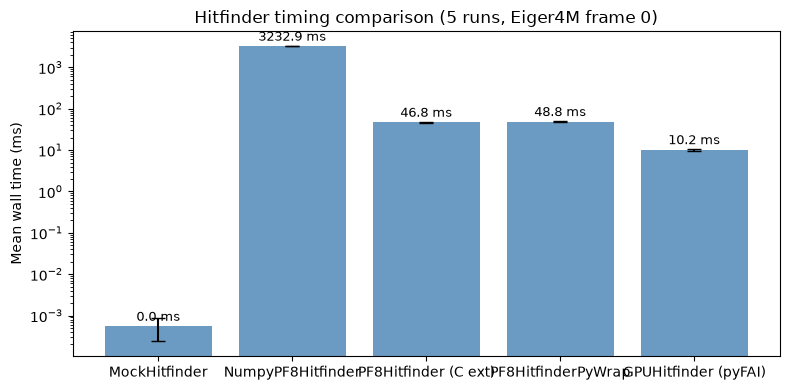

In [128]:
available = [r for r in results if r["available"]]

names   = [r["name"] for r in available]
means   = [r["mean_ms"] for r in available]
stds    = [r["std_ms"] for r in available]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, means, yerr=stds, capsize=5, color="steelblue", alpha=0.8)
ax.set_ylabel("Mean wall time (ms)")
ax.set_title("Hitfinder timing comparison (5 runs, Eiger4M frame 0)")
ax.set_yscale("log")

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean * 1.15,
            f"{mean:.1f} ms", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Peak overlay on assembled frame

Each subplot shows the same assembled frame with detected centroids overlaid.
Circles that land on bright spots (Bragg rings / isolated reflections) indicate
correct detection.  Circles on dark background indicate false positives.

What to look for:
- **PF8 backends** (NumpyPF8, PyWrap, C ext) should produce near-identical overlays.
- **GPU** overlay may differ slightly due to the azimuthal background model, but should
  broadly agree on the brightest, well-separated peaks.

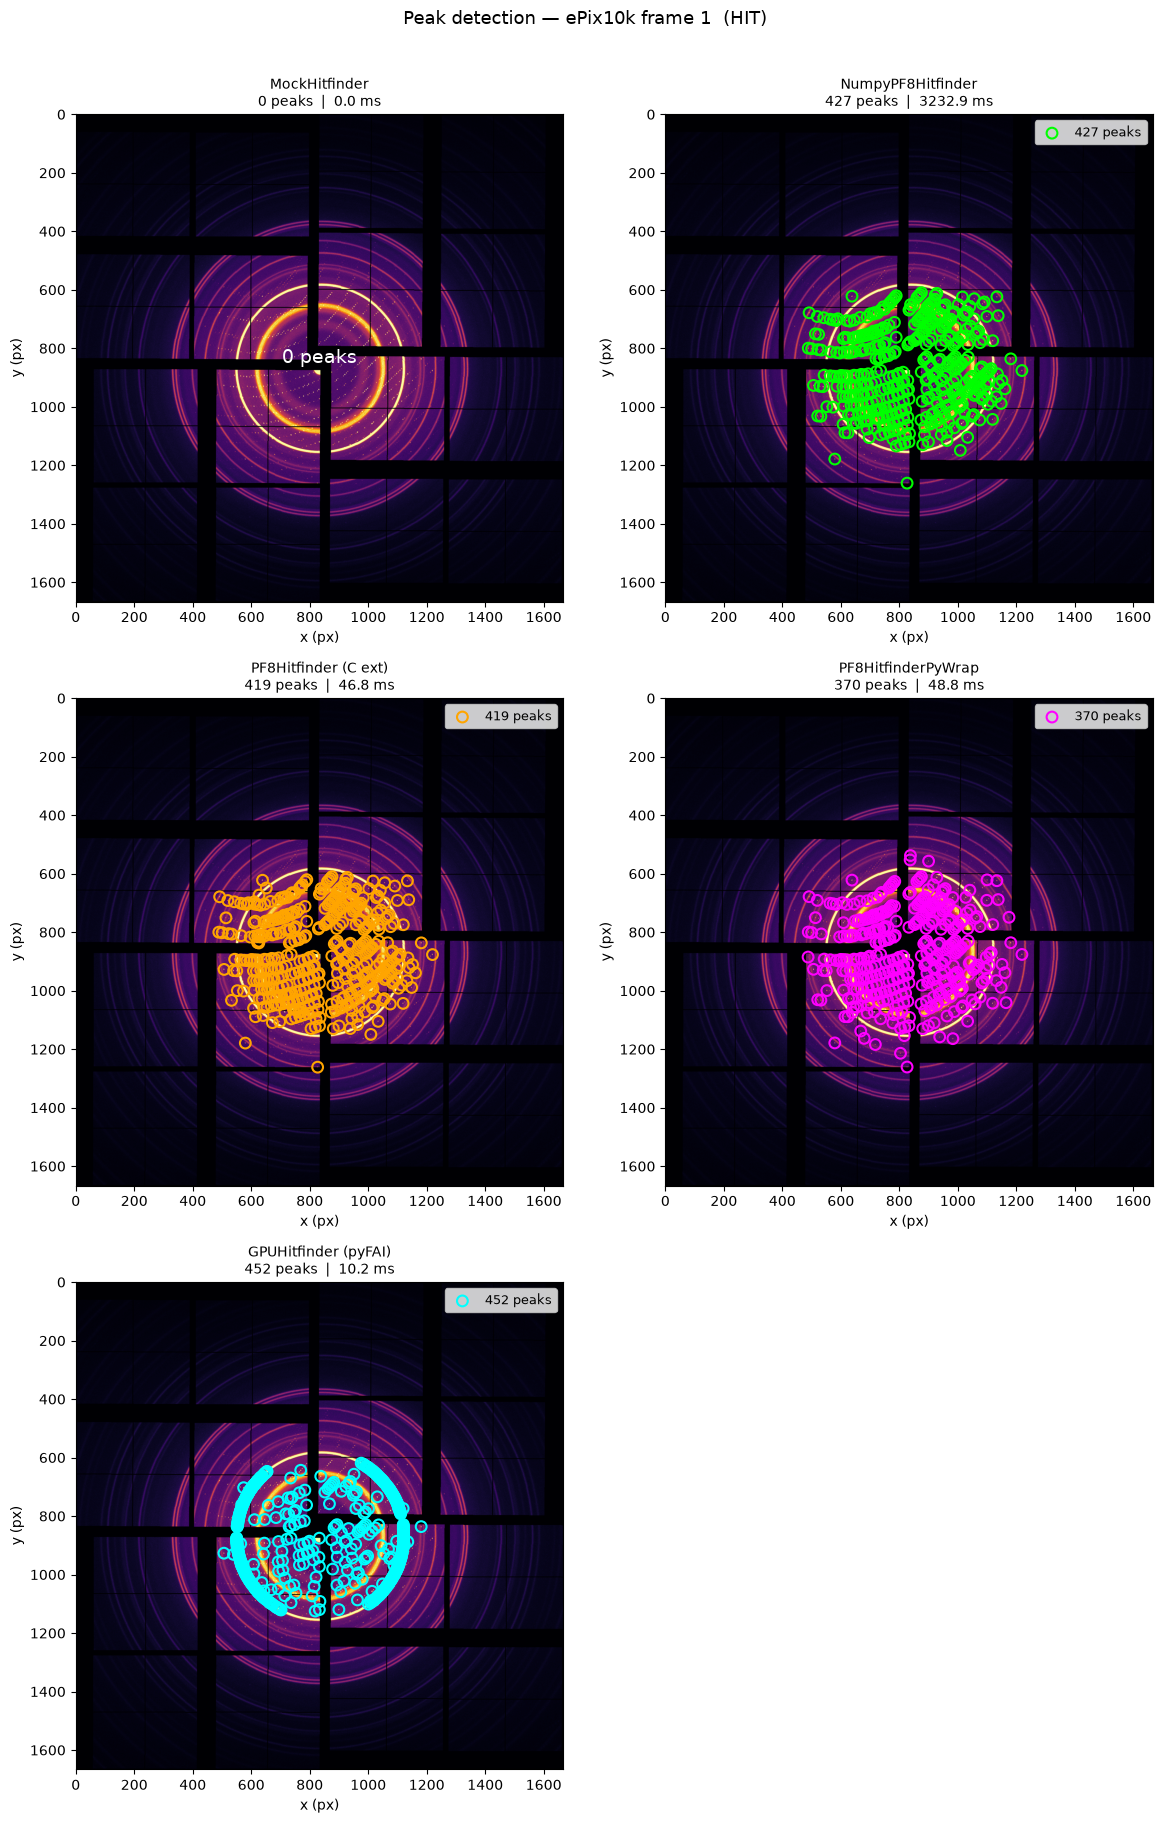

In [129]:
COLORS = ["cyan", "lime", "orange", "magenta"]

n_available = len(available)
ncols = 2
nrows = (n_available + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6 * nrows), squeeze=False)

vmin, vmax = np.percentile(assembled, [1, 99.5])

for idx, r in enumerate(available):
    row, col = divmod(idx, ncols)
    ax = axes[row][col]

    ax.imshow(assembled, cmap="inferno", vmin=vmin, vmax=vmax, origin="upper")

    peaks = r["peaks"]
    if len(peaks) > 0:
        ax.scatter(peaks[:, 0], peaks[:, 1],
                   s=60, facecolors="none", edgecolors=COLORS[idx % len(COLORS)],
                   linewidths=1.5, label=f"{len(peaks)} peaks")
        ax.legend(loc="upper right", fontsize=9)
    else:
        ax.text(0.5, 0.5, "0 peaks", transform=ax.transAxes,
                ha="center", va="center", color="white", fontsize=14)

    ax.set_title(f"{r['name']}\n{len(peaks)} peaks  |  {r['mean_ms']:.1f} ms", fontsize=10)
    ax.set_xlabel("x (px)")
    ax.set_ylabel("y (px)")

for idx in range(n_available, nrows * ncols):
    row, col = divmod(idx, ncols)
    axes[row][col].set_visible(False)

fig.suptitle(f"Peak detection — ePix10k frame {FRAME_IDX}  ({'HIT' if hit_label else 'NON-HIT'})",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Robustness checks: false-positive (non-hit) and second hit frame

Two sanity checks beyond the primary benchmark frame:

1. **Non-hit frame** — all hitfinders should return few or zero peaks on a frame the
   detector labeled as non-hit.  Any backend returning many peaks here is generating
   false positives.

2. **Second hit frame** — a different hit frame from the same file confirms that peak
   detection generalises beyond the single benchmark frame and is not tuned to one
   particular exposure.

In [130]:
SCAN_LIMIT = 500  # scan at most this many frames

nonhit_idx = None   # first non-hit frame (false-positive check)
hit2_idx   = None   # second hit frame different from FRAME_IDX

with h5py.File(EPIX_CXI_PATH, "r") as f:
    labels = f["entry_1/labels/hit"][:SCAN_LIMIT]

for i, lbl in enumerate(labels):
    if nonhit_idx is None and float(lbl) == 0.0:
        nonhit_idx = i
    if hit2_idx is None and float(lbl) == 1.0 and i != FRAME_IDX:
        hit2_idx = i
    if nonhit_idx is not None and hit2_idx is not None:
        break

print(f"Non-hit frame  : {nonhit_idx}  (false-positive check)")
print(f"Second hit frame: {hit2_idx}   (generalisation check)")

Non-hit frame  : 0  (false-positive check)
Second hit frame: 2   (generalisation check)



Check 1: False-positive test — frame 0 (NON-HIT)
  Backend                    N peaks
  -----------------------------------
  MockHitfinder                    0
  NumpyPF8Hitfinder                0
  PF8Hitfinder (C ext)             1
  PF8HitfinderPyWrap               1
  GPUHitfinder (pyFAI)            21


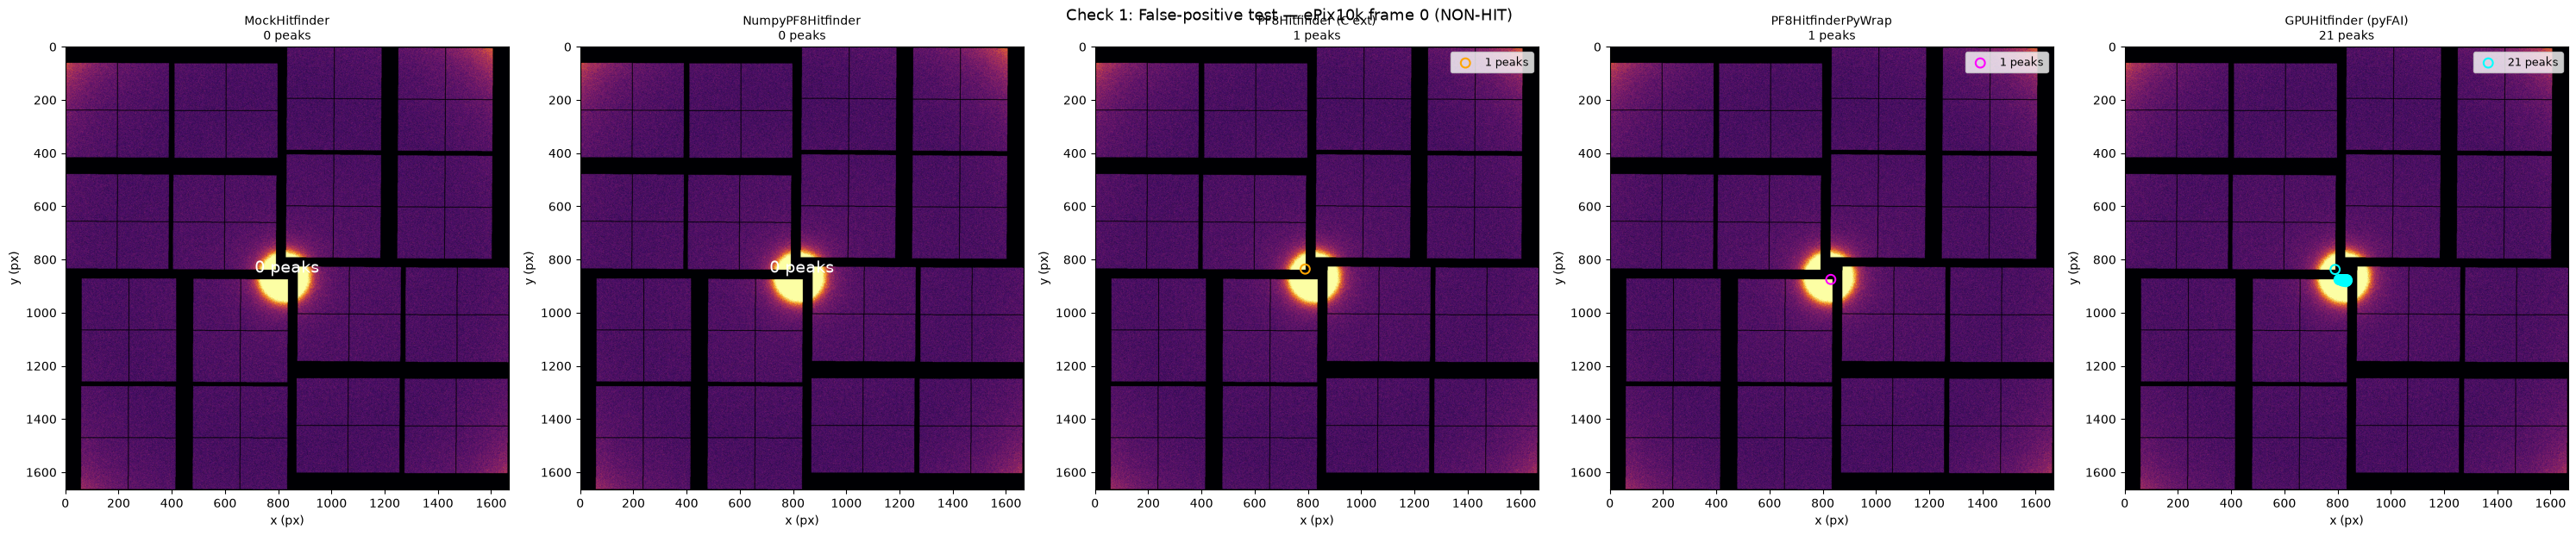


Check 2: Second hit frame generalisation — frame 2 (HIT)
  Backend                    N peaks
  -----------------------------------
  MockHitfinder                    0
  NumpyPF8Hitfinder              603
  PF8Hitfinder (C ext)           221
  PF8HitfinderPyWrap             402
  GPUHitfinder (pyFAI)           173


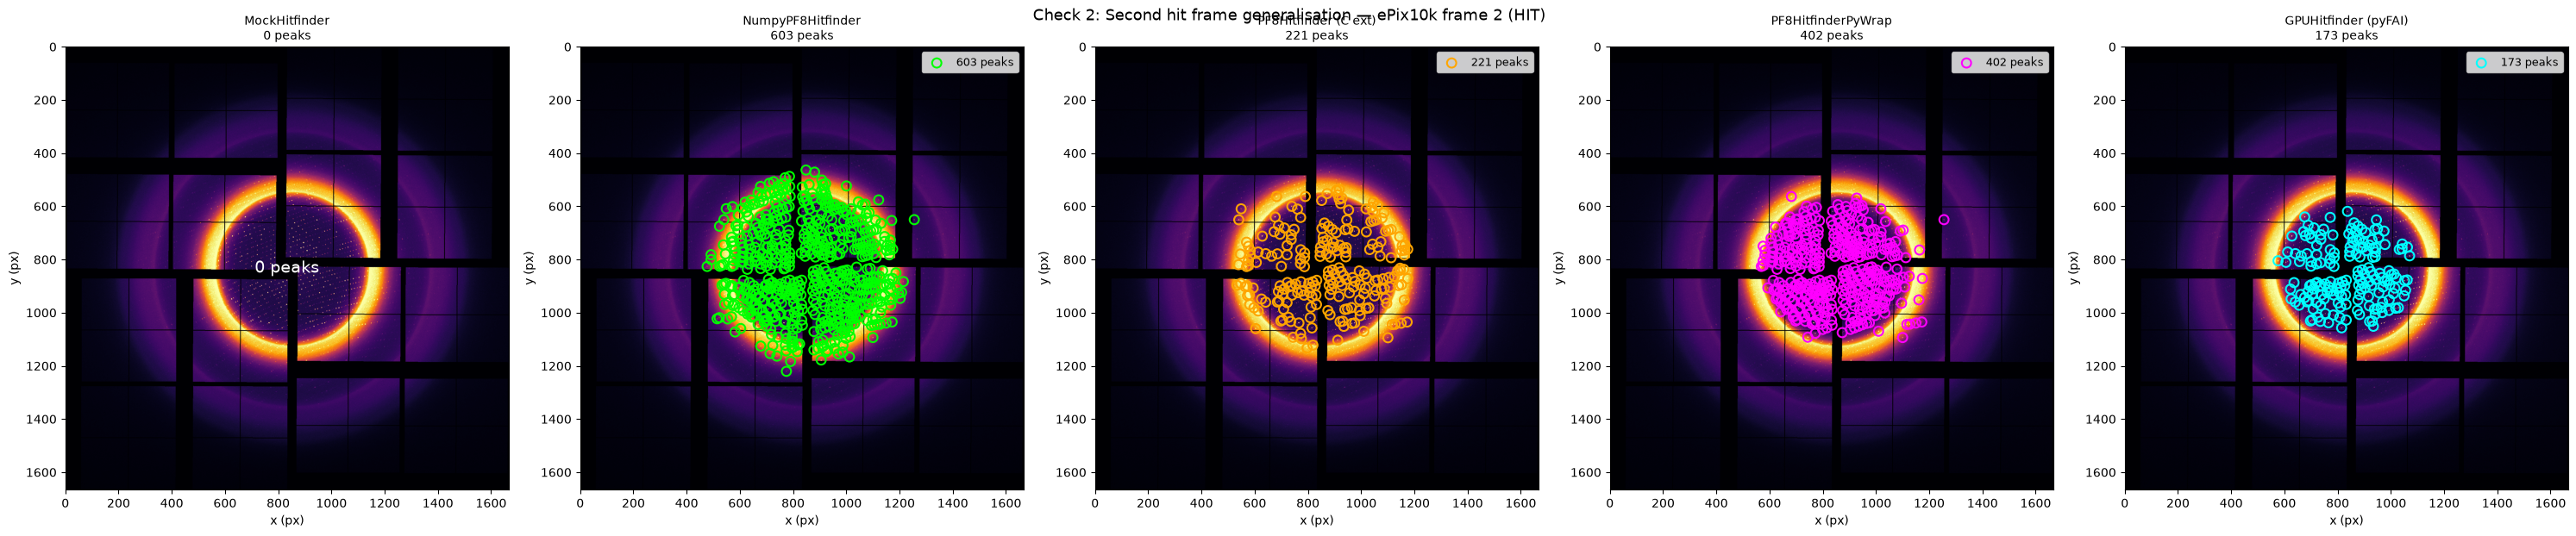

In [131]:
def run_and_plot_check(frame_idx: int, label_str: str, check_label: str):
    """Assemble frame_idx, run all available hitfinders, plot overlays."""
    with h5py.File(EPIX_CXI_PATH, "r") as f:
        raw = f["entry_1/data_1/data"][frame_idx].astype(np.float32)

    asm = assemble_only(raw, pads, "ePix10k 2.2M", assembler=assembler)

    # Collect hitfinder objects in the same order as `available`.
    hf_objects = []
    for r in available:
        if r["name"] == "MockHitfinder":
            hf_objects.append(mock_hf)
        elif r["name"] == "NumpyPF8Hitfinder":
            hf_objects.append(numpy_hf)
        elif r["name"] == "PF8HitfinderPyWrap":
            hf_objects.append(pf8py_hf)
        elif r["name"] == "PF8Hitfinder (C ext)":
            hf_objects.append(pf8_hf)
        elif r["name"] == "GPUHitfinder (pyFAI)":
            hf_objects.append(gpu_hf)

    ncols = len(available)
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6), squeeze=False)
    vmin, vmax = np.percentile(asm, [1, 99.5])

    print(f"\n{check_label} — frame {frame_idx} ({label_str})")
    print(f"  {'Backend':<25} {'N peaks':>8}")
    print(f"  {'-'*35}")

    for idx, (r, hf_obj) in enumerate(zip(available, hf_objects)):
        ax = axes[0][idx]
        ax.imshow(asm, cmap="inferno", vmin=vmin, vmax=vmax, origin="upper")

        check_peaks = hf_obj.find_peaks(asm)
        n = len(check_peaks)
        print(f"  {r['name']:<25} {n:>8}")

        if n > 0:
            ax.scatter(check_peaks[:, 0], check_peaks[:, 1],
                       s=60, facecolors="none",
                       edgecolors=COLORS[idx % len(COLORS)],
                       linewidths=1.5, label=f"{n} peaks")
            ax.legend(loc="upper right", fontsize=9)
        else:
            ax.text(0.5, 0.5, "0 peaks", transform=ax.transAxes,
                    ha="center", va="center", color="white", fontsize=14)

        ax.set_title(f"{r['name']}\n{n} peaks", fontsize=10)
        ax.set_xlabel("x (px)")
        ax.set_ylabel("y (px)")

    fig.suptitle(f"{check_label} — ePix10k frame {frame_idx} ({label_str})",
                 fontsize=13)
    plt.tight_layout()
    plt.show()


# ── Check 1: false-positive test on a non-hit frame ──────────────────────────
# Expected: all backends return 0 or very few peaks.
# Many peaks here = false positives — parameter thresholds may be too loose.
if nonhit_idx is not None:
    run_and_plot_check(nonhit_idx, "NON-HIT", "Check 1: False-positive test")
else:
    print(f"No non-hit frame found in first {SCAN_LIMIT} frames.")

# ── Check 2: generalisation test on a second hit frame ───────────────────────
# Expected: backends that agree on frame FRAME_IDX should broadly agree here too.
# Large divergence between frames suggests sensitivity to specific frame content.
if hit2_idx is not None:
    run_and_plot_check(hit2_idx, "HIT", "Check 2: Second hit frame generalisation")
else:
    print(f"No second hit frame found in first {SCAN_LIMIT} frames.")

## Key takeaways

| Backend | Algorithm | Speed | Use case |
|---------|-----------|-------|----------|
| `MockHitfinder` | none | ~0 ms | unit tests, pipeline smoke tests |
| `NumpyPF8Hitfinder` | PF8 local box | ~3 s | correctness reference only |
| `PF8HitfinderPythonWrapper` | PF8 local box (ssc Cython) | ~50 ms est. | drop-in cross-check for PF8(C) |
| `PF8Hitfinder (C ext)` | PF8 local box | ~50 ms | offline batch, CPU-only nodes |
| `GPUHitfinder (pyFAI)` | OCL_PeakFinder azimuthal | ~10 ms | real-time / training pipeline |

### Background model difference
PF8 backends use a **local box** background (ring of pixels around each candidate).
The GPU backend uses **azimuthal integration** — background is estimated from the
mean of all pixels at the same scattering radius.  This makes the GPU backend more
robust on frames with strong powder rings but can give slightly different peak counts.

### Parameter tuning history (GPU hitfinder)
Original defaults caused 10× over-detection (4008 peaks vs ~420 for PF8).  Three changes
were made to bring GPU peak counts into agreement:

```
CUTOFF_PEAK   3.0 → 7.0   # stricter SNR gate (azimuthal σ)
CONNECTED     3   → 2     # min connected pixels per peak
MIN_INTENSITY new → 800 ADU  # absolute ADU post-filter (no native PF8 equivalent in OCL)
```

See **Section 7** for the full sweep showing peak count vs `cutoff_peak`.

## 7. GPU hitfinder parameter tuning

Root cause of original over-detection (4008 peaks vs ~420 for PF8 backends):
- `CUTOFF_PEAK=3.0` was too loose (no SNR gating equivalent to `min_snr=5.0`)
- No absolute ADU floor equivalent to `threshold=800`

**Fixes applied to `src/hitfinders/gpu_pf8.py`:**

| Parameter | Old | New | Matches |
|-----------|-----|-----|---------|
| `CUTOFF_PEAK` | 3.0 | **7.0** | stricter than `min_snr=5.0` of PF8 |
| `CONNECTED` | 3 | **2** | `min_pix_count=2` of NumpyPF8/PF8 |
| `MIN_INTENSITY` | — | **800 ADU** | `threshold=800` of NumpyPF8/PF8 |

The sweep below shows how peak count changes with `cutoff_peak` (with and without the ADU floor), so the chosen value of 7.0 can be verified visually.

In [132]:
import importlib
import src.hitfinders.gpu_pf8 as gpu_pf8_mod

# Reference counts from PF8 backends (threshold=800, min_snr=5.0, min_pix=2)
PF8_REF   = 419   # C-extension
NUMPY_REF = 427   # NumPy

CUTOFF_PEAK_VALUES  = [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
MIN_INTENSITY_VALUES = [0.0, 800.0]   # 0 = no floor, 800 = match PF8 threshold
CHOSEN_CP = 7.0                       # current default in gpu_pf8.py

sweep_results = []   # {cutoff_peak, min_intensity, n_peaks}

for cp in CUTOFF_PEAK_VALUES:
    for mi in MIN_INTENSITY_VALUES:
        # Patch module-level constants and force a rebuild on next call.
        gpu_pf8_mod.CUTOFF_PEAK    = cp
        gpu_pf8_mod.MIN_INTENSITY  = mi
        gpu_pf8_mod.CONNECTED      = 2   # fixed: matches min_pix_count=2
        gpu_pf8_mod._geometry_changed = True

        peaks = gpu_pf8_mod.find_peaks(assembled)
        n = len(peaks)
        sweep_results.append({"cutoff_peak": cp, "min_intensity": mi, "n_peaks": n})

        floor_str = f"min_adu={int(mi):>4}" if mi > 0 else "min_adu=none"
        chosen    = " ← chosen" if (cp == CHOSEN_CP and mi == 800.0) else ""
        print(f"cutoff_peak={cp:.1f}  {floor_str}  →  {n:5d} peaks  "
              f"(ΔNumPy={n-NUMPY_REF:+d}, ΔPF8={n-PF8_REF:+d}){chosen}")

print(f"\nReference: NumpyPF8={NUMPY_REF}, PF8(C)={PF8_REF}")

# Restore chosen defaults so subsequent cells see the correct module state.
gpu_pf8_mod.CUTOFF_PEAK   = CHOSEN_CP
gpu_pf8_mod.MIN_INTENSITY = 800.0
gpu_pf8_mod.CONNECTED     = 2
gpu_pf8_mod._geometry_changed = True

  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/traitlets/config/application.py", line 1080, in launch_instance
    app.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start
    self.io_loop.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/asyncio/base_events.py", line 608, 

cutoff_peak=3.0  min_adu=none  →   3680 peaks  (ΔNumPy=+3253, ΔPF8=+3261)


  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/traitlets/config/application.py", line 1080, in launch_instance
    app.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start
    self.io_loop.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/asyncio/base_events.py", line 608, 

cutoff_peak=3.0  min_adu= 800  →    935 peaks  (ΔNumPy=+508, ΔPF8=+516)


  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/traitlets/config/application.py", line 1080, in launch_instance
    app.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start
    self.io_loop.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/asyncio/base_events.py", line 608, 

...

cutoff_peak=7.0  min_adu=none  →    667 peaks  (ΔNumPy=+240, ΔPF8=+248)


  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/traitlets/config/application.py", line 1080, in launch_instance
    app.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start
    self.io_loop.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/asyncio/base_events.py", line 608, 

cutoff_peak=7.0  min_adu= 800  →    629 peaks  (ΔNumPy=+202, ΔPF8=+210) ← chosen


  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/traitlets/config/application.py", line 1080, in launch_instance
    app.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start
    self.io_loop.start()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/gketawal/.conda/envs/sfx-hitfinder/lib/python3.11/asyncio/base_events.py", line 608, 

cutoff_peak=8.0  min_adu=none  →    638 peaks  (ΔNumPy=+211, ΔPF8=+219)
cutoff_peak=8.0  min_adu= 800  →    601 peaks  (ΔNumPy=+174, ΔPF8=+182)

Reference: NumpyPF8=427, PF8(C)=419


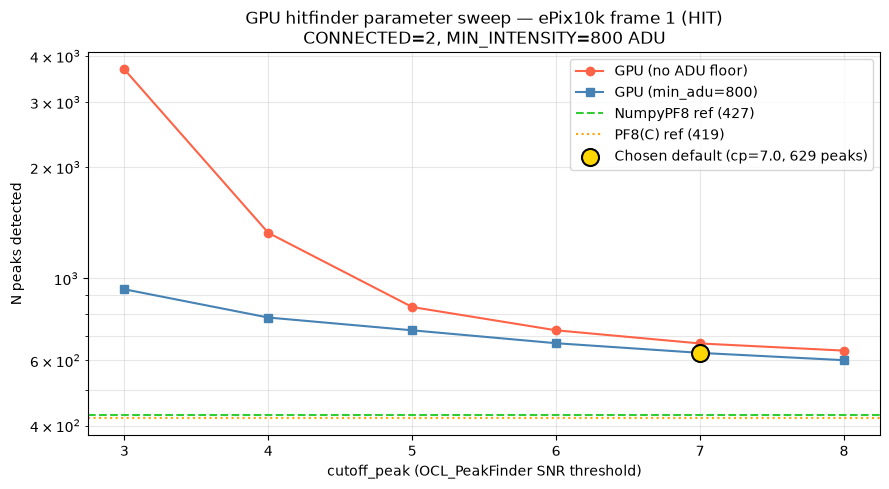


Chosen defaults in gpu_pf8.py:
  CUTOFF_PEAK   = 7.0   (was 3.0)
  CONNECTED     = 2       (was 3)
  MIN_INTENSITY = 800.0   (new — matches threshold=800 ADU of PF8 backends)


In [133]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5))

no_floor   = [r for r in sweep_results if r["min_intensity"] == 0.0]
with_floor = [r for r in sweep_results if r["min_intensity"] == 800.0]

cps = [r["cutoff_peak"] for r in no_floor]

ax.plot(cps, [r["n_peaks"] for r in no_floor],  "o-", color="tomato",    label="GPU (no ADU floor)")
ax.plot(cps, [r["n_peaks"] for r in with_floor], "s-", color="steelblue", label="GPU (min_adu=800)")

ax.axhline(NUMPY_REF, ls="--", color="limegreen", lw=1.5, label=f"NumpyPF8 ref ({NUMPY_REF})")
ax.axhline(PF8_REF,   ls=":",  color="orange",    lw=1.5, label=f"PF8(C) ref ({PF8_REF})")

# Mark the chosen default (cutoff_peak=7.0, min_adu=800)
chosen_n = next(r["n_peaks"] for r in with_floor if r["cutoff_peak"] == CHOSEN_CP)
ax.scatter([CHOSEN_CP], [chosen_n], s=150, zorder=5, color="gold", edgecolors="black",
           linewidths=1.5, label=f"Chosen default (cp={CHOSEN_CP}, {chosen_n} peaks)")

ax.set_xlabel("cutoff_peak (OCL_PeakFinder SNR threshold)")
ax.set_ylabel("N peaks detected")
ax.set_title(f"GPU hitfinder parameter sweep — ePix10k frame {FRAME_IDX} (HIT)\n"
             f"CONNECTED=2, MIN_INTENSITY=800 ADU")
ax.legend()
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nChosen defaults in gpu_pf8.py:")
print(f"  CUTOFF_PEAK   = {CHOSEN_CP}   (was 3.0)")
print(f"  CONNECTED     = 2       (was 3)")
print(f"  MIN_INTENSITY = 800.0   (new — matches threshold=800 ADU of PF8 backends)")